<a href="https://colab.research.google.com/github/Ishan-malinda/Machine-Learning-Algorithm-for-Bank-Loan-System-Prediction/blob/main/Classification_Modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Classification Modelling and Hyperparameter Tuning  
Machine Learning & Data Mining    
Author: W.F. ISHAN MALINDA SOVIS  


Purpose: Control pandas display settings to prevent data truncation when displaying the dataset

In [3]:
# Import pandas before setting display options
import pandas as pd
# Set maximum rows pandas will display to 500
pd.set_option('display.max_rows', 500)
# Set maximum columns pandas will display to 500
pd.set_option('display.max_columns', 500)
# Set display width to 150 to prevent line wrapping
pd.set_option('display.width', 150)

Purpose: Load the prepared classification dataset saved from Notebook 1

In [4]:
# Load the prepared classification dataset from Notebook 1
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ML for BANK system prediction/Data/loan_classification_prepared.csv')

Purpose: Display first 15 rows to verify the prepared dataset loaded correctly

In [5]:
# Display first 15 rows to confirm dataset loaded correctly
data.head(15)

,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status
0,0.3125,0.093788,3,0.020000,1,1.000000,0.558824,0.228916,0,0.321429,0
1,0.3125,0.045258,0,0.020000,2,1.000000,0.676471,0.469880,0,0.428571,0
2,0.3125,0.066887,0,0.060000,5,0.855072,0.529412,0.277108,0,0.392857,0
3,0.3125,0.076907,0,0.060000,0,0.710145,0.647059,0.204819,0,0.321429,0
4,0.3125,0.067412,0,0.020000,2,0.710145,0.794118,0.265060,0,0.535714,0
5,0.3125,0.039983,0,0.013333,0,0.710145,0.617647,0.373494,0,0.321429,0
6,0.3125,0.039983,0,0.060000,5,0.710145,0.852941,0.361446,0,0.535714,0
7,0.3125,0.029433,2,0.033333,5,0.710145,0.647059,0.506024,1,0.357143,0
8,0.3125,0.042621,0,0.020000,2,0.710145,0.676471,0.349398,0,0.500000,0
9,0.3125,0.034706,2,0.126667,1,0.710145,0.852941,0.433735,0,0.428571,0


Purpose: Check data types and non-null counts to confirm dataset is clean and ready for modelling

In [6]:
# Display data types and non-null counts to verify dataset is clean
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58636 entries, 0 to 58635
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      58636 non-null  float64
 1   income                   58636 non-null  float64
 2   home_ownership           58636 non-null  int64  
 3   emplyment_length         58636 non-null  float64
 4   loan_intent              58636 non-null  int64  
 5   loan_amount              58636 non-null  float64
 6   loan_interest_rate       58636 non-null  float64
 7   loan_income_ratio        58636 non-null  float64
 8   payment_default_on_file  58636 non-null  int64  
 9   credit_history_length    58636 non-null  float64
 10  loan_approval_status     58636 non-null  int64  
dtypes: float64(7), int64(4)
memory usage: 4.9 MB


Purpose: Declare input features (X) and target output variable (y) for classification modelling

In [7]:
# Define the list of input feature column names for classification modelling
feature_cols = ['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent',
                'loan_amount', 'loan_interest_rate', 'loan_income_ratio',
                'payment_default_on_file', 'credit_history_length']
# Assign input features to X
X = data[feature_cols]
# Assign target variable loan_approval_status to y
y = data['loan_approval_status']
# Display shape of X to confirm correct number of features and instances
print("X shape:", X.shape)
# Display shape of y to confirm target variable
print("y shape:", y.shape)
# Display all feature names used for modelling
print("Features used:", list(X.columns))

X shape: (58636, 10)
y shape: (58636,)
Features used: ['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length']


Purpose: Import train_test_split function from sklearn to split data into training and test subsets

In [8]:
# Import train_test_split function for splitting data into training and test subsets
from sklearn.model_selection import train_test_split

Purpose: Split dataset into 80% training and 20% test subsets.  
random_state=42 ensures all three models are tested on the exact same test instances.  
stratify=y ensures the ratio of Approved to Rejected labels is identical in both training and test subsets.

In [9]:
# Split data into training and test subsets at 80/20 ratio
# random_state=42 ensures reproducible and identical splits across all models
# stratify=y preserves the class ratio of Approved vs Rejected in both subsets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                     random_state=42,
                                                     stratify=y)
# Confirm training subset size
print("X_train shape:", X_train.shape)
# Confirm test subset size
print("X_test shape:", X_test.shape)
# Confirm class ratio is preserved in training subset
print("Training class distribution:")
print(y_train.value_counts())
# Confirm class ratio is preserved in test subset
print("Test class distribution:")
print(y_test.value_counts())

X_train shape: (46908, 10)
X_test shape: (11728, 10)
Training class distribution:
loan_approval_status
0    40229
1     6679
Name: count, dtype: int64
Test class distribution:
loan_approval_status
0    10058
1     1670
Name: count, dtype: int64


Purpose: Import Logistic Regression algorithm from sklearn linear model module

In [10]:
# Import Logistic Regression classification algorithm from sklearn
from sklearn.linear_model import LogisticRegression

Purpose: Instantiate the Logistic Regression modelling algorithm

In [11]:
# Create a Logistic Regression model instance
logreg = LogisticRegression()

Purpose: Train the Logistic Regression model on the training subset so it learns the relationship between input features and loan approval status

In [12]:
# Train the Logistic Regression model using the training subset
logreg.fit(X_train, y_train)

LogisticRegression()

Purpose: Use the trained Logistic Regression model to predict loan approval status on the training subset to assess how well it learned

In [13]:
# Predict loan approval status on the training subset
y_pred_train = logreg.predict(X_train)

Purpose: Use the trained Logistic Regression model to predict loan approval status on the unseen test subset

In [14]:
# Predict loan approval status on the unseen test subset
y_pred = logreg.predict(X_test)

Purpose: Create a comparison dataframe showing actual vs predicted loan approval status for the test subset

In [15]:
# Create a dataframe comparing actual vs predicted loan approval status
Comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
# Display the comparison dataframe
Comparison_df

,Actual,Predicted
34228,0,0
21615,0,0
17523,0,0
16006,0,0
1315,1,1
...,...,...
30923,0,0
57648,0,0
58632,0,0
15946,0,0


Purpose: Calculate the test accuracy score of the Logistic Regression model on the unseen test subset

In [16]:
# Import accuracy_score metric from sklearn
from sklearn.metrics import accuracy_score
# Calculate and display the test accuracy score of the Logistic Regression model
accuracy = accuracy_score(y_test, y_pred)
# Print the accuracy score
print("LR Test Accuracy:", accuracy)

LR Test Accuracy: 0.8908594815825375


Purpose: Calculate and display the confusion matrix for the Logistic Regression model on the test subset

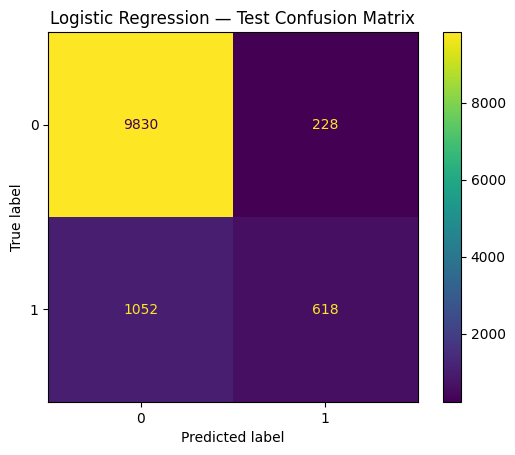

In [17]:
# Import confusion matrix and display tools from sklearn
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
# Calculate the confusion matrix using test labels and predictions
cm = confusion_matrix(y_test, y_pred, labels=logreg.classes_)
# Create a display object with class labels
disp = ConfusionMatrixDisplay(cm, display_labels=logreg.classes_)
# Plot and display the confusion matrix with title
disp.plot()
import matplotlib.pyplot as plt
plt.title("Logistic Regression — Test Confusion Matrix")
plt.show()

Purpose: Generate the full classification report for the Logistic Regression model showing all evaluation metrics

In [18]:
# Import classification report from sklearn metrics
from sklearn.metrics import classification_report
# Generate and print the full classification report for LR test predictions
print("Logistic Regression — Classification Report")
print(classification_report(y_test, y_pred))

Logistic Regression — Classification Report
              precision    recall  f1-score   support

           0       0.90      0.98      0.94     10058
           1       0.73      0.37      0.49      1670

    accuracy                           0.89     11728
   macro avg       0.82      0.67      0.72     11728
weighted avg       0.88      0.89      0.88     11728



Purpose: Plot the AUC-ROC curve for the Logistic Regression model to evaluate discriminative ability between Approved and Rejected classes

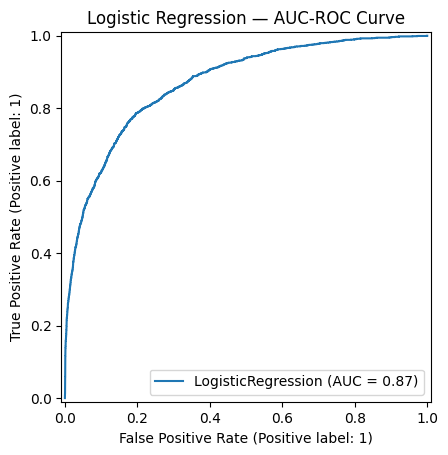

In [19]:
# Import RocCurveDisplay from sklearn metrics
from sklearn.metrics import RocCurveDisplay
# Plot the AUC-ROC curve for the Logistic Regression model
logreg_roc = RocCurveDisplay.from_estimator(logreg, X_test, y_test)
# Add title to the plot
import matplotlib.pyplot as plt
plt.title("Logistic Regression — AUC-ROC Curve")
plt.show()

Purpose: Import the K-Nearest Neighbours classification algorithm from sklearn

In [20]:
# Import KNeighborsClassifier from sklearn neighbors module
from sklearn.neighbors import KNeighborsClassifier

Purpose: Instantiate the KNN modelling algorithm. k=5 is used as the starting value — an odd number to avoid ties in majority voting

In [21]:
# Create a KNN model instance with k=5 as initial number of neighbours
knn = KNeighborsClassifier(n_neighbors=5)

Purpose: Train the KNN model on the training subset so it stores training instances for distance-based prediction

In [22]:
# Train the KNN model using the training subset
knn.fit(X_train, y_train)

KNeighborsClassifier()

Purpose: Use the trained KNN model to predict loan approval status on the unseen test subset

In [23]:
# Predict loan approval status on the unseen test subset using KNN
y_pred_knn = knn.predict(X_test)

Purpose: Calculate the test accuracy score of the KNN model on the unseen test subset

In [24]:
# Calculate and display the test accuracy score of the KNN model
accuracy_knn = accuracy_score(y_test, y_pred_knn)
# Print the KNN accuracy score
print("KNN Test Accuracy:", accuracy_knn)

KNN Test Accuracy: 0.9142223738062756


Purpose: Calculate and display the confusion matrix for the KNN model on the test subset

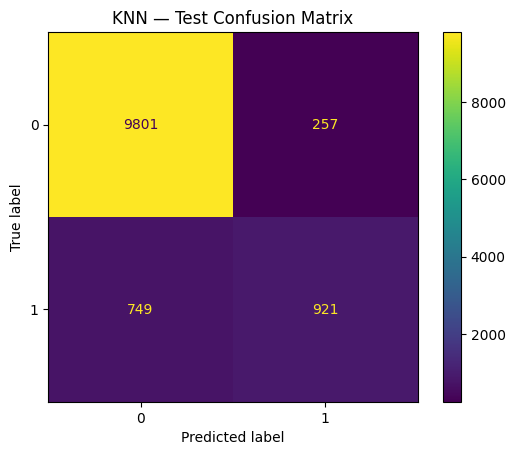

In [25]:
# Calculate the confusion matrix for KNN test predictions
cm_knn = confusion_matrix(y_test, y_pred_knn, labels=knn.classes_)
# Create display object with class labels
disp_knn = ConfusionMatrixDisplay(cm_knn, display_labels=knn.classes_)
# Plot and display the KNN confusion matrix
disp_knn.plot()
# Add title to identify this matrix
plt.title("KNN — Test Confusion Matrix")
plt.show()

Purpose: Generate the full classification report for the KNN model showing all evaluation metric

In [26]:
# Generate and print the full classification report for KNN test predictions
print("KNN — Classification Report")
print(classification_report(y_test, y_pred_knn))

KNN — Classification Report
              precision    recall  f1-score   support

           0       0.93      0.97      0.95     10058
           1       0.78      0.55      0.65      1670

    accuracy                           0.91     11728
   macro avg       0.86      0.76      0.80     11728
weighted avg       0.91      0.91      0.91     11728



Purpose: Plot the AUC-ROC curve for the KNN model to evaluate its discriminative ability between Approved and Rejected classes

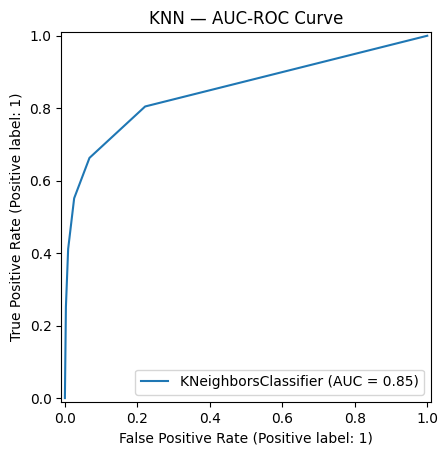

In [27]:
# Plot the AUC-ROC curve for the KNN model
knn_roc = RocCurveDisplay.from_estimator(knn, X_test, y_test)
# Add title to identify this curve
plt.title("KNN — AUC-ROC Curve")
plt.show()

Purpose: Import, instantiate and train the Naive Bayes classification model using the training subset

In [28]:
# Import GaussianNB from sklearn naive_bayes module
from sklearn.naive_bayes import GaussianNB
# Create a Gaussian Naive Bayes model instance
nb = GaussianNB()
# Train the Naive Bayes model using the training subset
nb.fit(X_train, y_train)

GaussianNB()

Purpose: Use the trained Naive Bayes model to predict loan approval status on the unseen test subset

In [29]:
# Predict loan approval status on the unseen test subset using Naive Bayes
y_pred_nb = nb.predict(X_test)

Purpose: Calculate the test accuracy score of the Naive Bayes model on the unseen test subset

In [30]:
# Calculate and display the test accuracy score of the Naive Bayes model
accuracy_nb = accuracy_score(y_test, y_pred_nb)
# Print the Naive Bayes accuracy score
print("Naive Bayes Test Accuracy:", accuracy_nb)

Naive Bayes Test Accuracy: 0.848055934515689


Purpose: Calculate and display the confusion matrix for the Naive Bayes model on the test subset

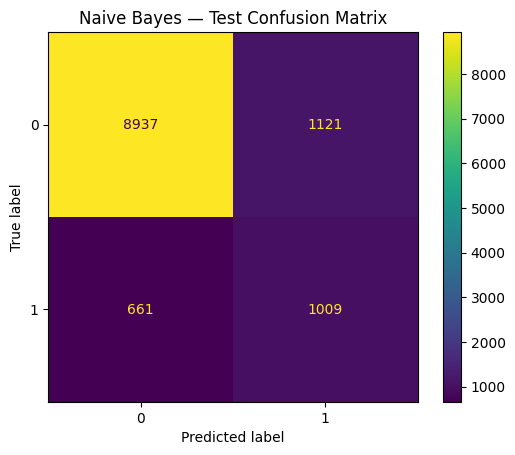

In [31]:
# Calculate the confusion matrix for Naive Bayes test predictions
cm_nb = confusion_matrix(y_test, y_pred_nb, labels=nb.classes_)
# Create display object with class labels
disp_nb = ConfusionMatrixDisplay(cm_nb, display_labels=nb.classes_)
# Plot and display the Naive Bayes confusion matrix
disp_nb.plot()
# Add title to identify this matrix
plt.title("Naive Bayes — Test Confusion Matrix")
plt.show()

Purpose: Generate the full classification report for the Naive Bayes model showing all evaluation metrics

In [32]:
# Generate and print the full classification report for Naive Bayes test predictions
print("Naive Bayes — Classification Report")
print(classification_report(y_test, y_pred_nb))

Naive Bayes — Classification Report
              precision    recall  f1-score   support

           0       0.93      0.89      0.91     10058
           1       0.47      0.60      0.53      1670

    accuracy                           0.85     11728
   macro avg       0.70      0.75      0.72     11728
weighted avg       0.87      0.85      0.86     11728



Purpose: Plot the AUC-ROC curve for the Naive Bayes model to evaluate its discriminative ability between Approved and Rejected classes

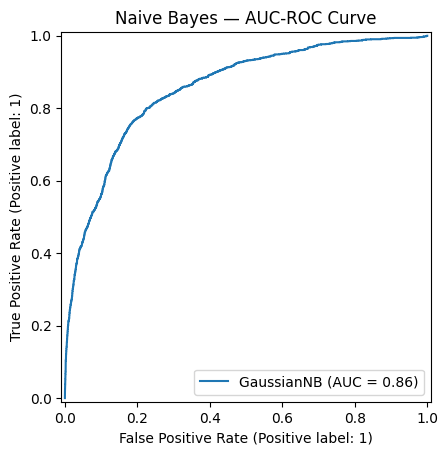

In [33]:
# Plot the AUC-ROC curve for the Naive Bayes model
nb_roc = RocCurveDisplay.from_estimator(nb, X_test, y_test)
# Add title to identify this curve
plt.title("Naive Bayes — AUC-ROC Curve")
plt.show()

Purpose: Import GridSearchCV from sklearn to perform exhaustive hyperparameter search using cross-validation to find the best KNN configuration

In [34]:
# Import GridSearchCV for exhaustive hyperparameter tuning with cross-validation
from sklearn.model_selection import GridSearchCV

Purpose: Define the hyperparameter grid for KNN and apply GridSearchCV to find the best combination of n_neighbors, metric and weights using 5-fold cross-validation

In [35]:
# Define the hyperparameter grid to search for KNN
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'metric': ['euclidean', 'manhattan'],
    'weights': ['uniform', 'distance']
}
# Create a new KNN instance for tuning
knn_model = KNeighborsClassifier()
# Apply GridSearchCV with 5-fold cross-validation scoring on recall for class 1
knn_gscv = GridSearchCV(knn_model, param_grid, cv=5, scoring='recall')
# Fit GridSearchCV on the training subset to find best hyperparameter combination
knn_gscv.fit(X_train, y_train)
# Display the best hyperparameter configuration found
print("Best hyperparameters:", knn_gscv.best_params_)

Best hyperparameters: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}


Purpose: Use the optimised KNN model with best hyperparameter configuration to predict loan approval status on the test subset

In [36]:
# Predict loan approval status using the optimised KNN model on the test subset
y_pred_knn_tuned = knn_gscv.predict(X_test)

Purpose: Display the confusion matrix for the tuned KNN model to compare performance before and after hyperparameter tuning

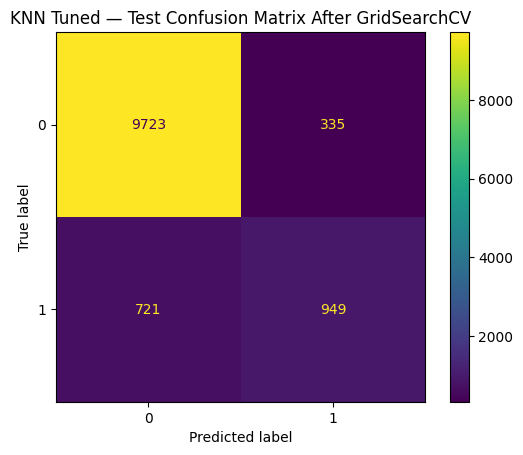

In [37]:
# Calculate confusion matrix for the tuned KNN model
cm_knn_tuned = confusion_matrix(y_test, y_pred_knn_tuned, labels=knn_gscv.classes_)
# Create display object for tuned KNN confusion matrix
disp_knn_tuned = ConfusionMatrixDisplay(cm_knn_tuned, display_labels=knn_gscv.classes_)
# Plot and display the tuned KNN confusion matrix
disp_knn_tuned.plot()
# Add title to clearly identify this as the tuned model result
plt.title("KNN Tuned — Test Confusion Matrix After GridSearchCV")
plt.show()

Purpose: Generate classification report for the tuned KNN model to document all metric scores after hyperparameter optimisation

In [38]:
# Generate and print classification report for the tuned KNN model
print("KNN Tuned — Classification Report After GridSearchCV")
print(classification_report(y_test, y_pred_knn_tuned))

KNN Tuned — Classification Report After GridSearchCV
              precision    recall  f1-score   support

           0       0.93      0.97      0.95     10058
           1       0.74      0.57      0.64      1670

    accuracy                           0.91     11728
   macro avg       0.84      0.77      0.80     11728
weighted avg       0.90      0.91      0.90     11728



Purpose: Plot AUC-ROC curve for the tuned KNN model to evaluate discriminative ability after optimisation

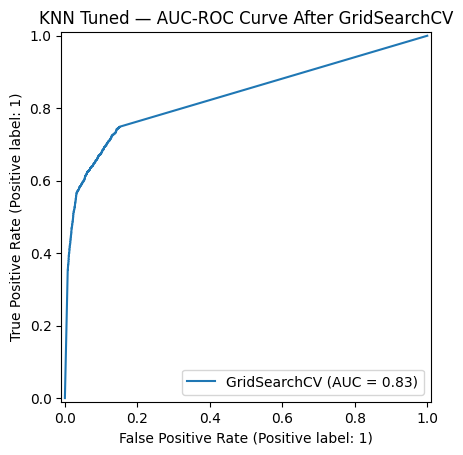

In [39]:
# Plot AUC-ROC curve for the tuned KNN model
knn_tuned_roc = RocCurveDisplay.from_estimator(knn_gscv, X_test, y_test)
# Add title to identify this as the tuned model curve
plt.title("KNN Tuned — AUC-ROC Curve After GridSearchCV")
plt.show()